In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import itertools
import re
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [58]:
def process_and_plot_folder(folder_path):
    folder_name = os.path.basename(folder_path.strip('/\\'))
    print(f"\n" + "="*50)
    print(f" PROCESSING FOLDER: {folder_name.upper()} ")
    print( "="*50)
    
    file_pattern = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(file_pattern)
    
    if not all_files:
        print(f"⚠️ No CSV files found in directory: '{folder_path}'")
        return

    df_list = []
    for f in all_files:
        try:
            df = pd.read_csv(f)
            if not df.empty:
                df_list.append(df)
        except Exception as e:
            print(f"Could not read {f}: {e}")
            
    if not df_list:
        print(f"⚠️ All CSV files in '{folder_path}' were empty.")
        return
        
    raw_df = pd.concat(df_list, ignore_index=True)
    
    # Standardize string data
    raw_df['Game'] = raw_df['Game'].astype(str).str.strip()
    raw_df['Algorithm'] = raw_df['Algorithm'].astype(str).str.strip()

    def extract_game_num(game_str):
        match = re.search(r'\d+', str(game_str))
        return int(match.group()) if match else 999

    raw_df['Game_Num'] = raw_df['Game'].apply(extract_game_num)

    all_algorithms = raw_df['Algorithm'].dropna().unique()
    game_meta = raw_df[['Game', 'Game_Num', 'Nodes', 'Edges']].drop_duplicates(subset=['Game']).dropna()

    master_grid = pd.DataFrame(
        list(itertools.product(game_meta['Game'], all_algorithms)),
        columns=['Game', 'Algorithm']
    ).merge(game_meta, on='Game', how='left')

    final_df = master_grid.merge(
        raw_df[['Game', 'Algorithm', 'Status', 'Time_ms', 'Peak_Memory_MB']], 
        on=['Game', 'Algorithm'], 
        how='left'
    )

    final_df['Status'] = final_df['Status'].fillna('DNF')
    final_df.loc[final_df['Time_ms'].isna(), 'Status'] = 'DNF'
    final_df.loc[final_df['Peak_Memory_MB'].isna(), 'Status'] = 'DNF'
    
    final_df = final_df.sort_values(by=['Game_Num', 'Algorithm']).reset_index(drop=True)

    matrix_df = final_df.pivot(index='Algorithm', columns='Game_Num', values='Status')
    matrix_numeric = matrix_df.map(lambda x: 1 if x == 'OK' else 0) # Modern pandas map

    plt.figure(figsize=(12, 3.5))
    sns.heatmap(matrix_numeric, cmap=['#e74c3c', '#2ecc71'], cbar=False, linewidths=2, linecolor='white')
    plt.title(f'[{folder_name.upper()}] Completion Matrix (Green = OK, Red = DNF)', fontsize=14, weight='bold', pad=15)
    plt.xlabel('Game Number', fontsize=11)
    plt.ylabel('Algorithm', fontsize=11)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    success_df = final_df[final_df['Status'] == 'OK']
    
    if success_df.empty:
        print(f"❌ No successful ('OK') runs to chart performance lines for {folder_name}.")
        return

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.lineplot(data=success_df, x='Game_Num', y='Time_ms', hue='Algorithm', 
                 marker='o', linewidth=2.5, markersize=8, ax=ax)
    ax.set_yscale('log') 
    plt.title(f'[{folder_name.upper()}] Execution Time Scaling', fontsize=14, weight='bold')
    plt.xlabel('Game Number', fontsize=11)
    plt.ylabel('Execution Time (ms) - Log Scale', fontsize=11)
    plt.xticks(game_meta['Game_Num'].unique())
    plt.legend(title='Algorithm', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.lineplot(data=success_df, x='Game_Num', y='Peak_Memory_MB', hue='Algorithm', 
                 marker='s', linewidth=2.5, markersize=8, ax=ax)
    plt.title(f'[{folder_name.upper()}] Memory Footprint Scaling', fontsize=14, weight='bold')
    plt.xlabel('Game Number', fontsize=11)
    plt.ylabel('Peak Memory Usage (MB)', fontsize=11)
    plt.xticks(game_meta['Game_Num'].unique())
    plt.legend(title='Algorithm', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


 PROCESSING FOLDER: TC 


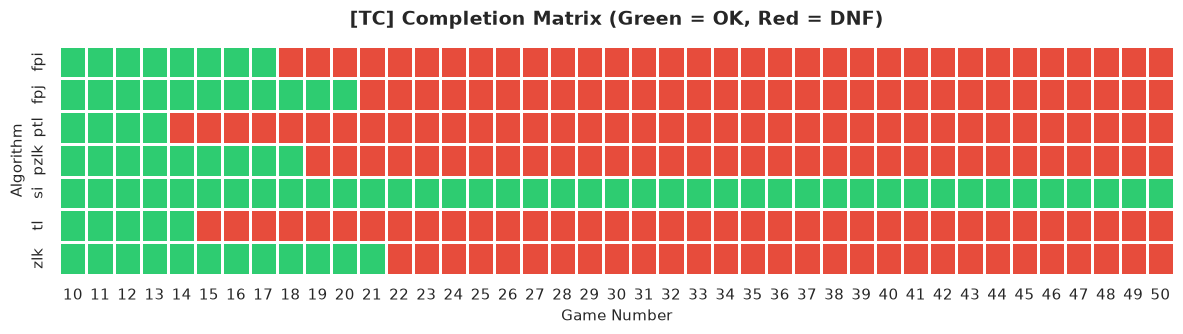

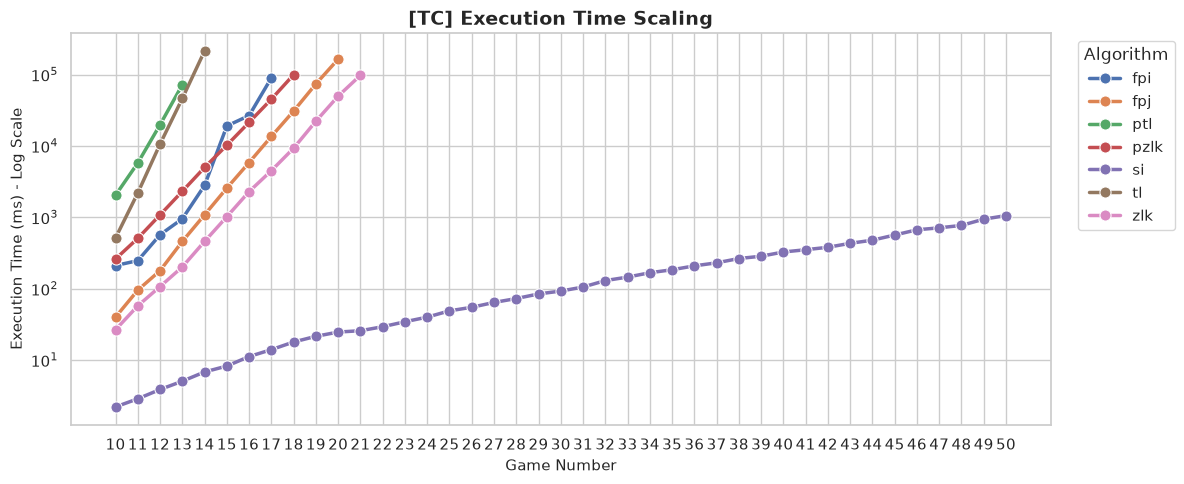

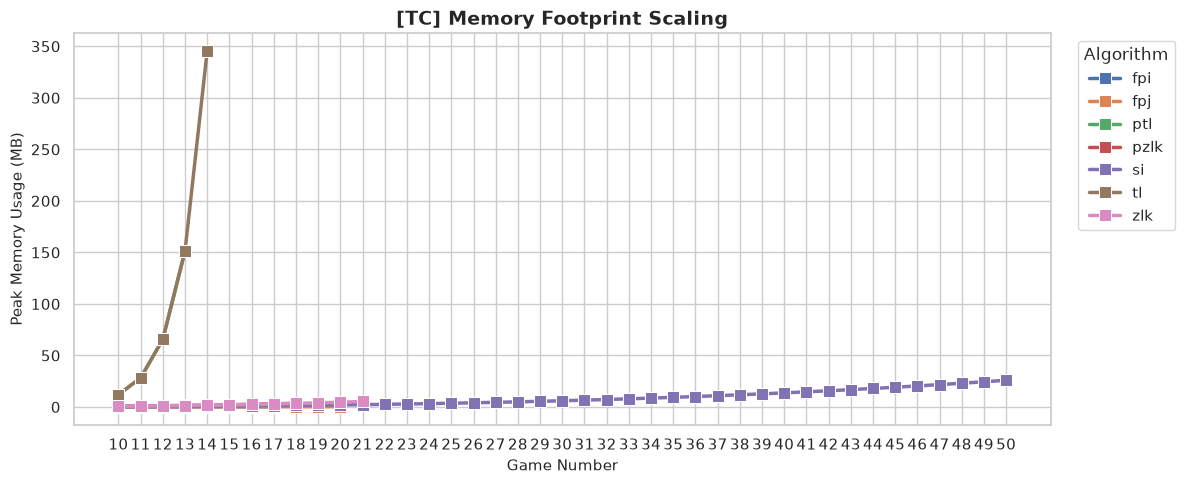


 PROCESSING FOLDER: SYMSI 


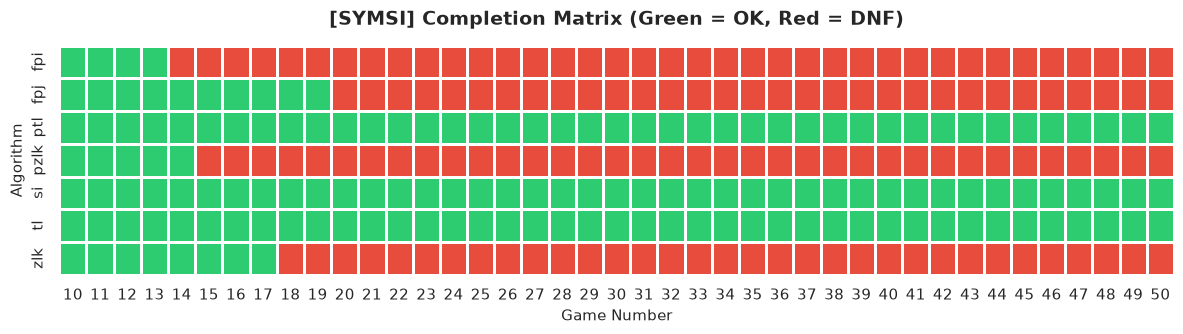

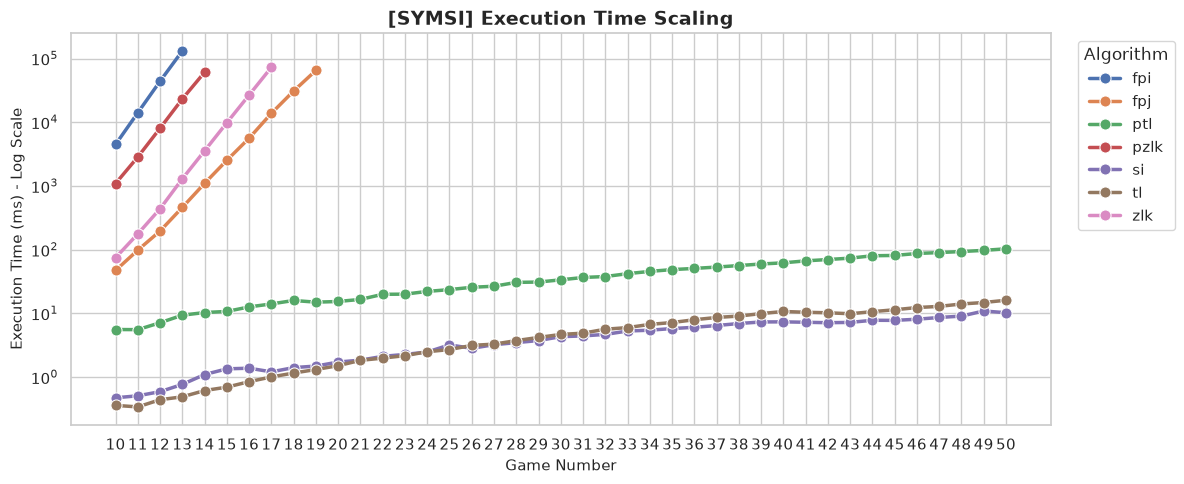

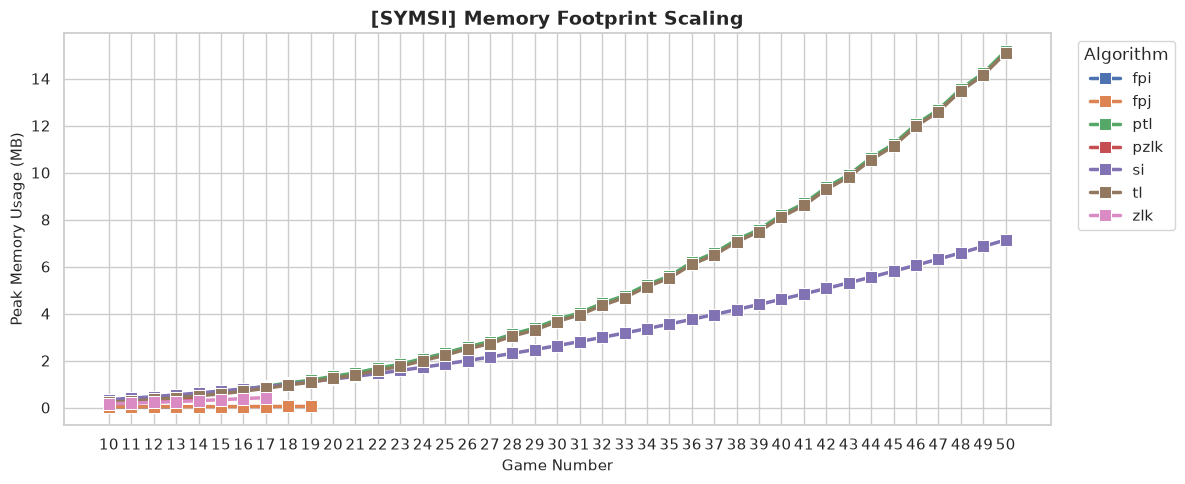


 PROCESSING FOLDER: M 


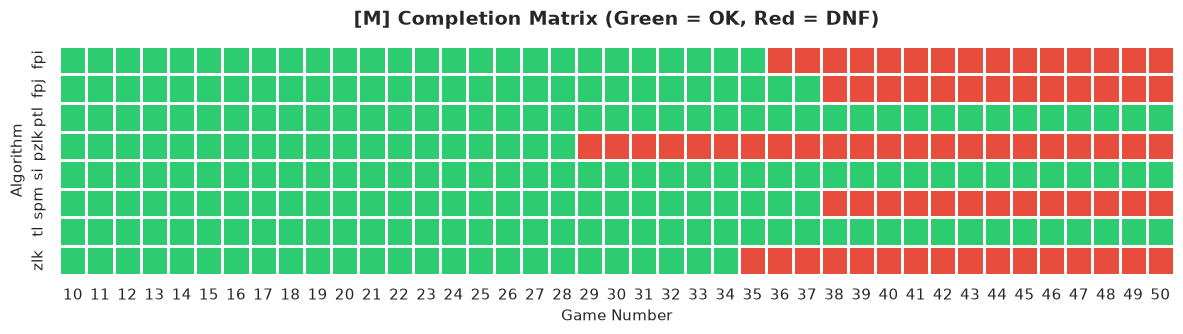

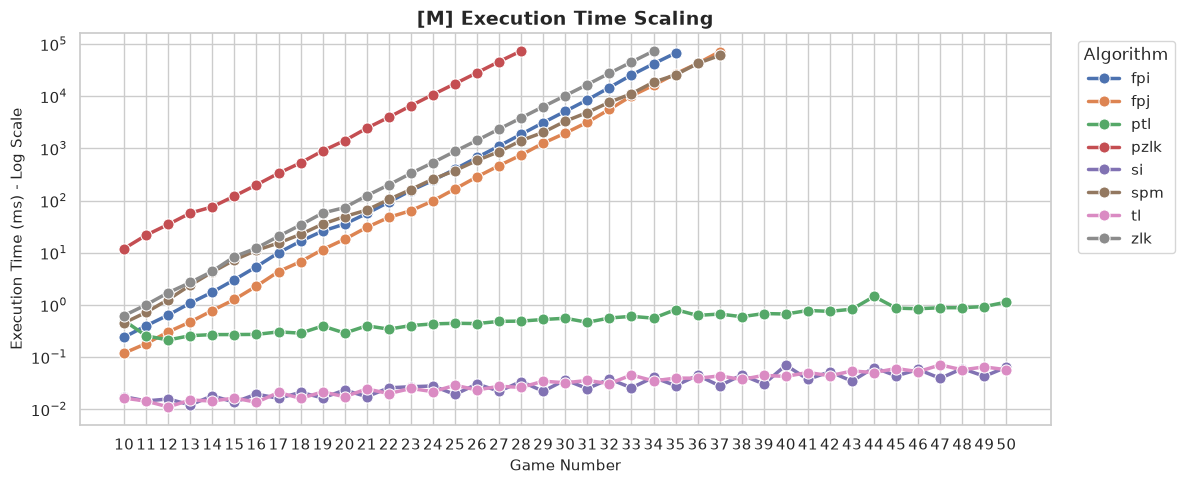

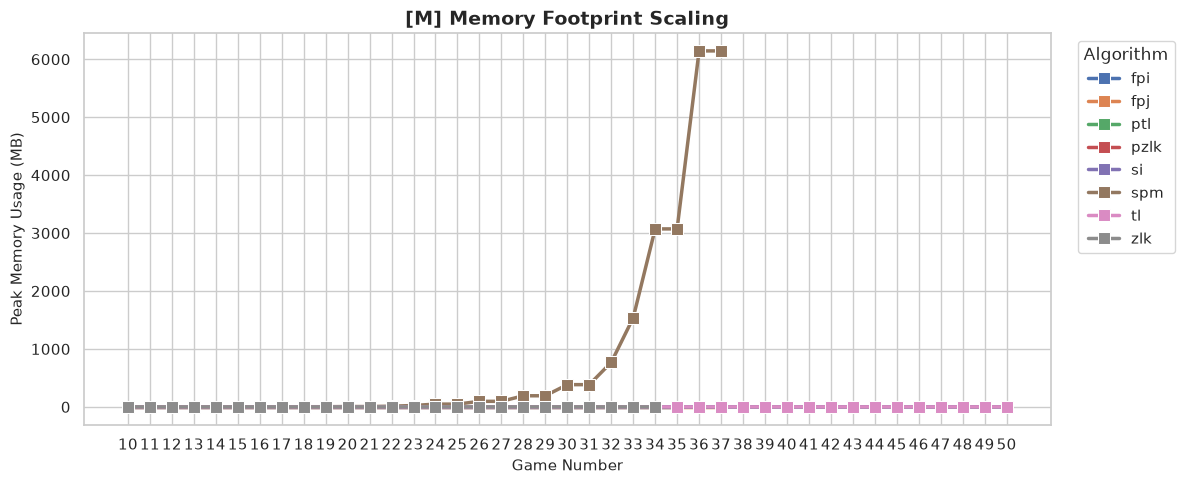


 PROCESSING FOLDER: DP 


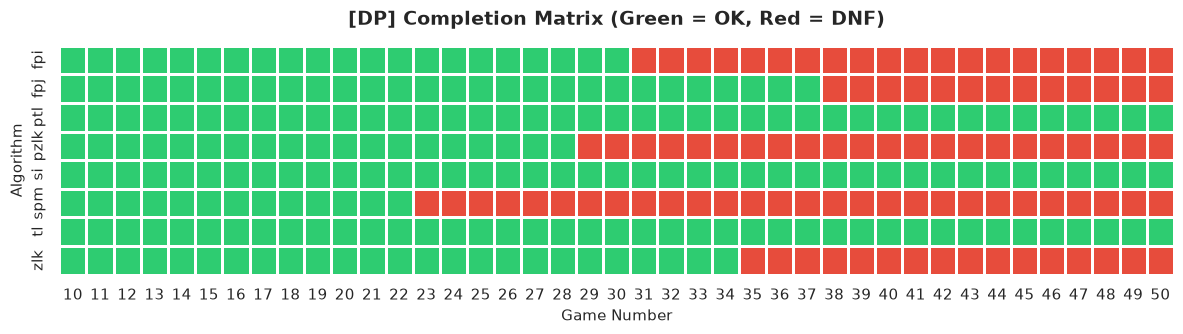

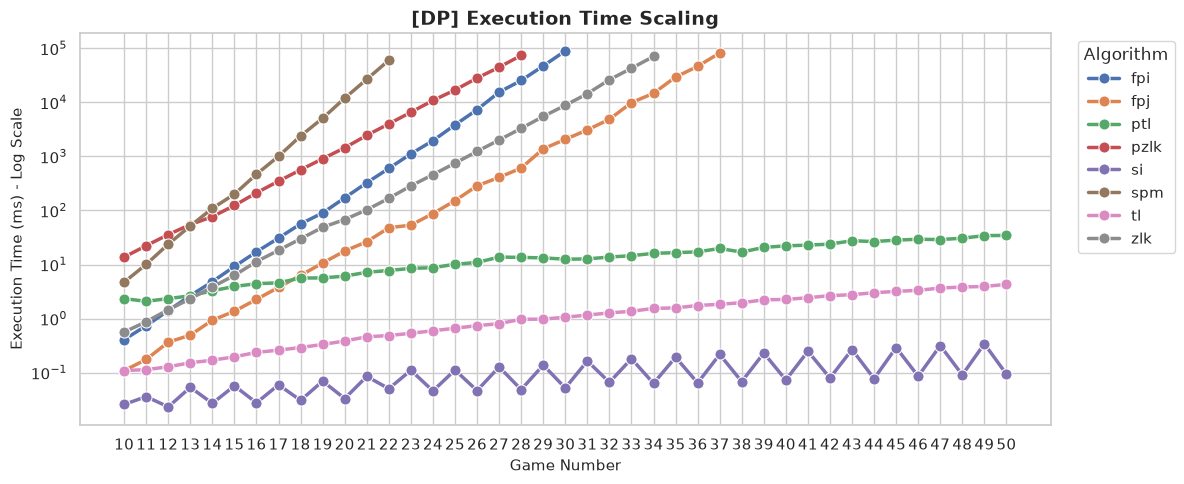

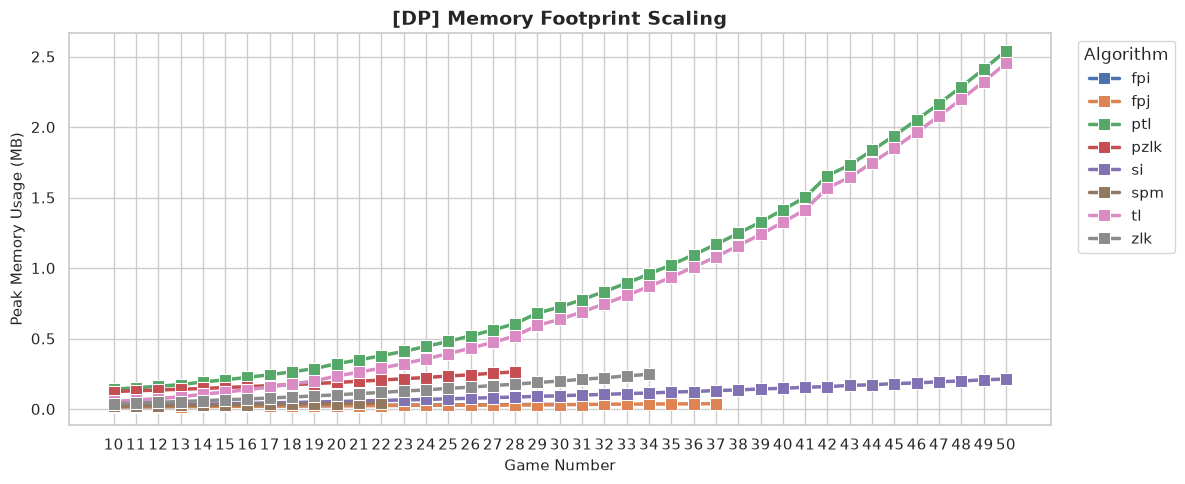


 PROCESSING FOLDER: CORE 


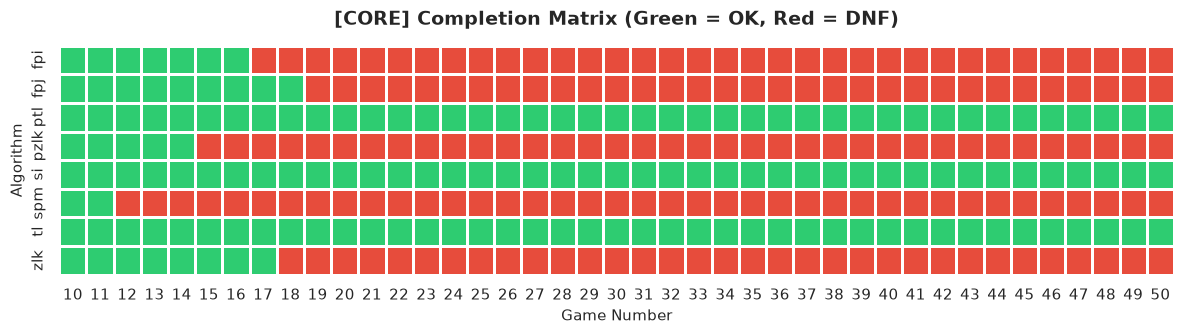

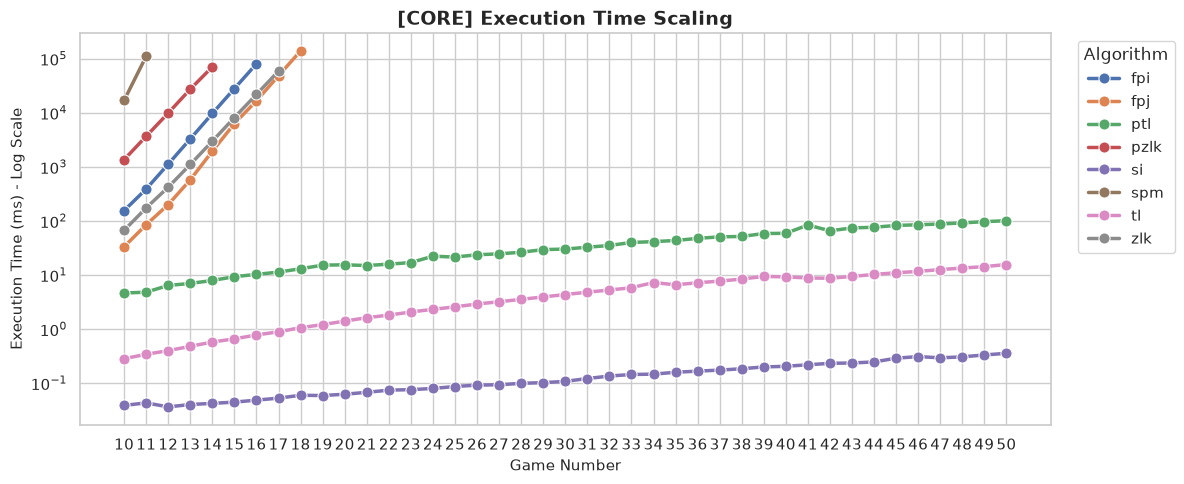

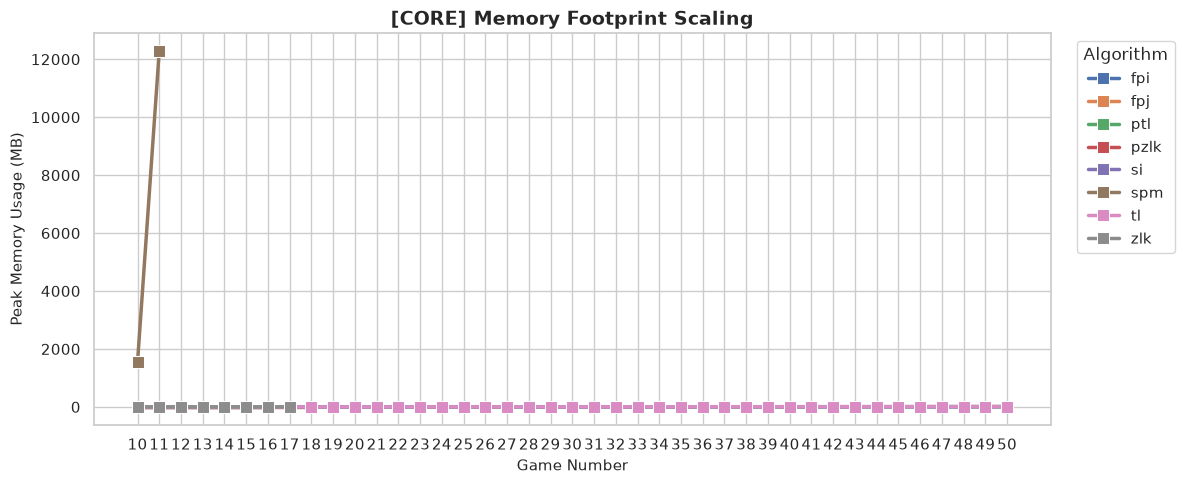

In [ ]:
target_folders = [
    "./tc+",
    "./tc",
    "./symsi",
    "./m",
    "./dp",
    "./core",
]

for folder in target_folders:
    if os.path.exists(folder):
        process_and_plot_folder(folder)
    else:
        print(f"⚠️ Folder not found: '{folder}'")

In [60]:
folder_path = "./random"
file_pattern = os.path.join(folder_path, "output_random_*.csv")
all_files = glob.glob(file_pattern)

print(f"Found {len(all_files)} random dataset files.")

df_list = []
for f in all_files:
    try:
        df = pd.read_csv(f)
        if not df.empty:
            df_list.append(df)
    except Exception as e:
        print(f"Error reading {f}: {e}")

raw_df = pd.concat(df_list, ignore_index=True)

raw_df['Game'] = raw_df['Game'].astype(str).str.strip()
raw_df['Algorithm'] = raw_df['Algorithm'].astype(str).str.strip()
raw_df['Nodes'] = pd.to_numeric(raw_df['Nodes'])

all_algorithms = raw_df['Algorithm'].dropna().unique()

unique_instances = raw_df[['Nodes', 'Game']].drop_duplicates()

grid_rows = []
for _, row in unique_instances.iterrows():
    for alg in all_algorithms:
        grid_rows.append({'Nodes': row['Nodes'], 'Game': row['Game'], 'Algorithm': alg})
master_grid = pd.DataFrame(grid_rows)

final_df = master_grid.merge(
    raw_df[['Nodes', 'Game', 'Algorithm', 'Status', 'Time_ms', 'Peak_Memory_MB']],
    on=['Nodes', 'Game', 'Algorithm'],
    how='left'
)

final_df['Status'] = final_df['Status'].fillna('DNF')
final_df.loc[final_df['Time_ms'].isna(), 'Status'] = 'DNF'
final_df.loc[final_df['Peak_Memory_MB'].isna(), 'Status'] = 'DNF'

final_df = final_df.sort_values(by=['Nodes', 'Game', 'Algorithm']).reset_index(drop=True)

print("\nProcessing complete! Top of the processed master grid:")
display(final_df.head(10))

Found 9 random dataset files.

Processing complete! Top of the processed master grid:


,Nodes,Game,Algorithm,Status,Time_ms,Peak_Memory_MB
0,10,Random_1,fpi,OK,0.005741,0.091242
1,10,Random_1,fpj,OK,0.002555,0.091099
2,10,Random_1,ptl,OK,0.076145,0.092213
3,10,Random_1,pzlk,OK,0.382410,0.092144
4,10,Random_1,si,OK,0.006853,0.092793
5,10,Random_1,spm,OK,0.013867,0.005241
6,10,Random_1,tl,OK,0.008155,0.005287
7,10,Random_1,zlk,OK,0.008657,0.005306
8,10,Random_10,fpi,OK,0.005700,0.091494
9,10,Random_10,fpj,OK,0.002906,0.091351


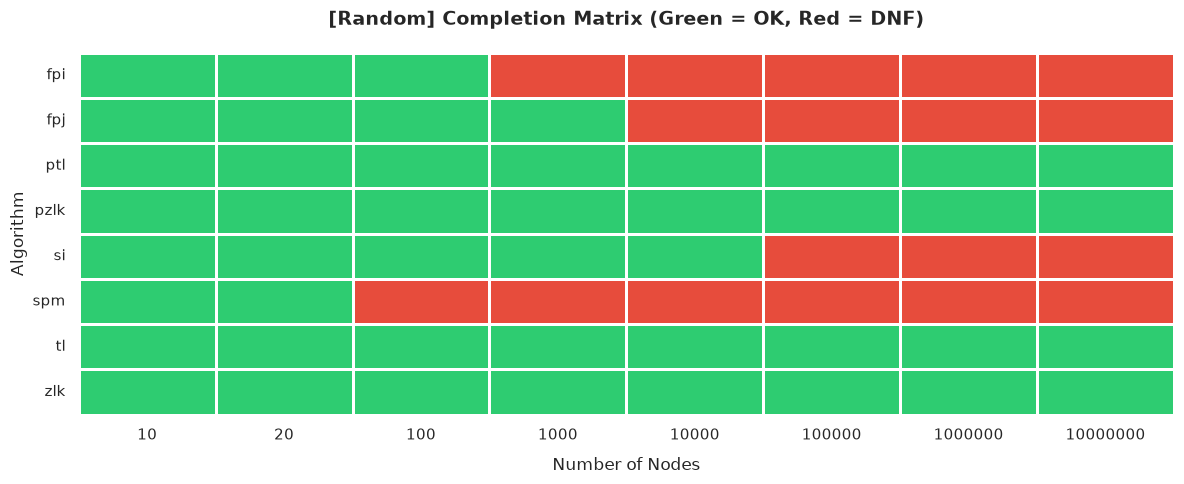

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

final_df['Nodes'] = pd.to_numeric(final_df['Nodes'], errors='coerce')

agg_df = final_df.groupby(['Algorithm', 'Nodes'])['Status'].apply(
    lambda x: 1 if (x == 'OK').all() else 0
).reset_index()

matrix_numeric = agg_df.pivot(index='Algorithm', columns='Nodes', values='Status')

matrix_numeric = matrix_numeric.reindex(columns=sorted(matrix_numeric.columns))

plt.figure(figsize=(12, 5))
sns.heatmap(
    matrix_numeric, 
    cmap=['#e74c3c', '#2ecc71'],
    fmt="",
    cbar=False, 
    linewidths=2, 
    linecolor='white',
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('[Random] Completion Matrix (Green = OK, Red = DNF)', fontsize=14, weight='bold', pad=20)
plt.xlabel('Number of Nodes', fontsize=12, labelpad=10)
plt.ylabel('Algorithm', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

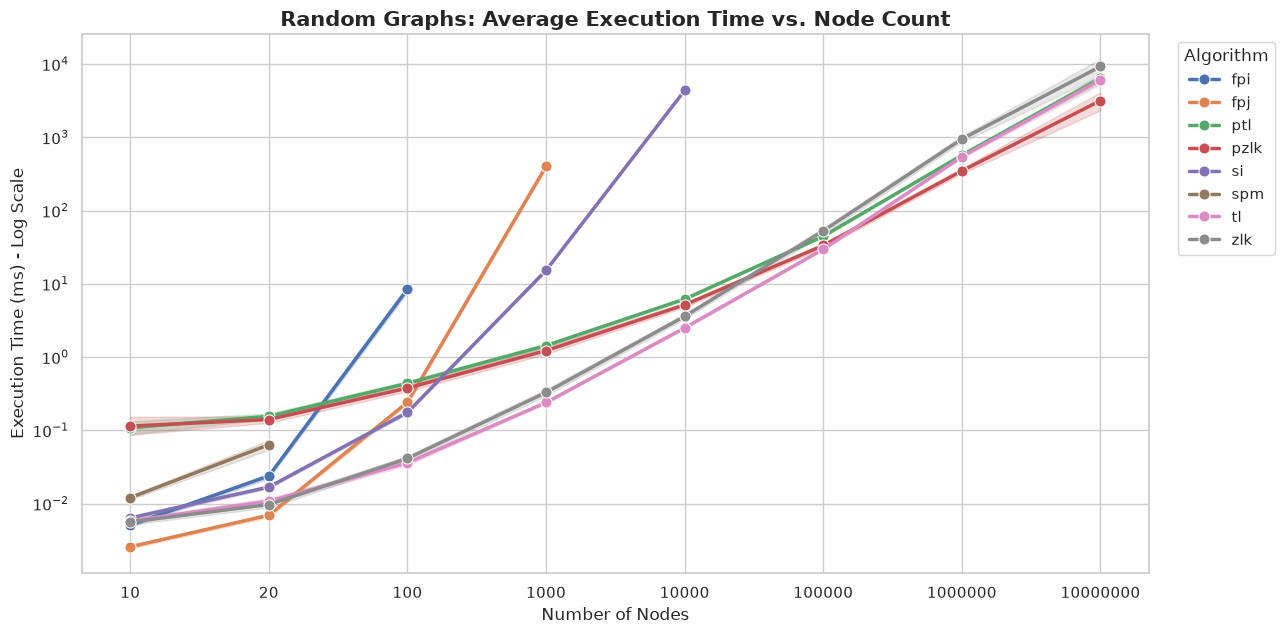

In [62]:
success_df = final_df[final_df['Status'] == 'OK'].copy()

success_df = success_df.sort_values('Nodes')
success_df['Nodes_Label'] = success_df['Nodes'].astype(str)

plt.figure(figsize=(13, 6.5))
ax = sns.lineplot(
    data=success_df, 
    x='Nodes_Label', 
    y='Time_ms', 
    hue='Algorithm', 
    marker='o', 
    linewidth=2.5, 
    markersize=8,
    sort=False
)

ax.set_yscale('log')
plt.title('Random Graphs: Average Execution Time vs. Node Count', fontsize=15, weight='bold')
plt.xlabel('Number of Nodes', fontsize=12)
plt.ylabel('Execution Time (ms) - Log Scale', fontsize=12)
plt.legend(title='Algorithm', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

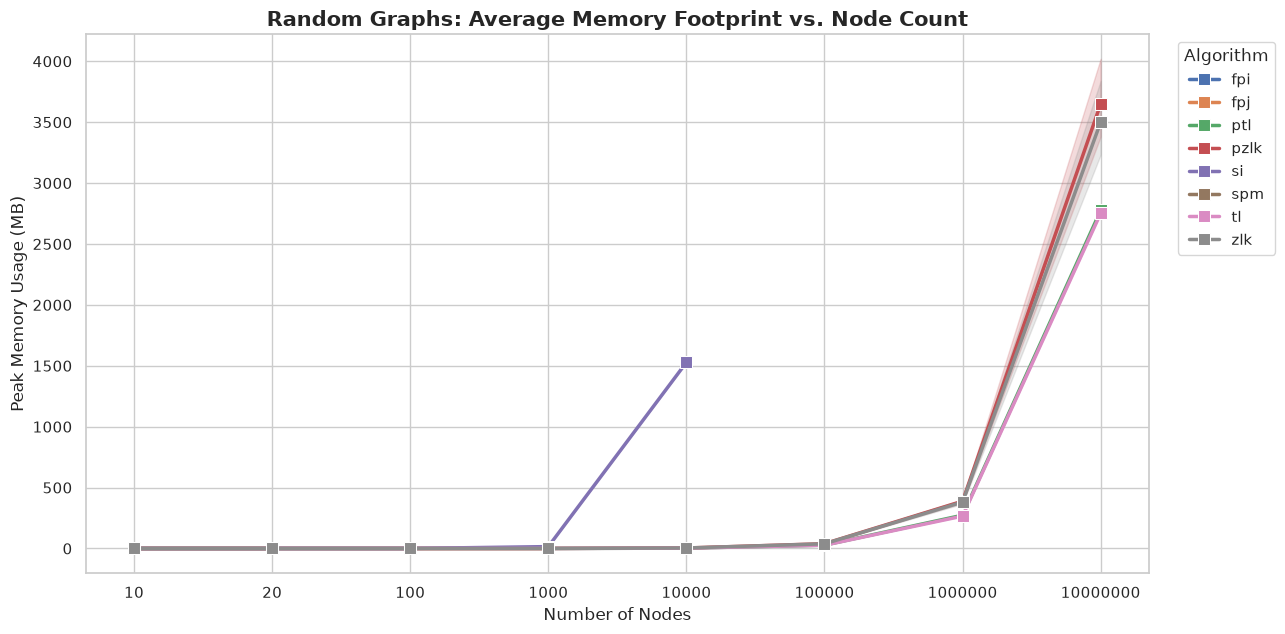

In [63]:
plt.figure(figsize=(13, 6.5))
ax = sns.lineplot(
    data=success_df, 
    x='Nodes_Label', 
    y='Peak_Memory_MB', 
    hue='Algorithm', 
    marker='s', 
    linewidth=2.5, 
    markersize=8,
    sort=False
)

plt.title('Random Graphs: Average Memory Footprint vs. Node Count', fontsize=15, weight='bold')
plt.xlabel('Number of Nodes', fontsize=12)
plt.ylabel('Peak Memory Usage (MB)', fontsize=12)
plt.legend(title='Algorithm', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()